## PA1: Segmentação de Instâncias com Arquiteturas da Aula
##### Disciplina: Aprendizado Profundo (Deep Learning) — FGV EMAp
##### Professor: Prof. Dario Oliveira | Monitor: Erick Brito
##### Equipe: Jaime Willian Carneiro da Silva e Luiz Eduardo Bravin

### 1. Importações

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *

import torch
from torch.utils.data import DataLoader, random_split
import numpy as np
import cv2 as cv
from pathlib import Path
import time

ModuleNotFoundError: No module named 'evaluating'

### 2. Configurações

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)
PATH_TRAIN = Path('../data/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
print(f'Device: {DEVICE}')

Device: xpu


### 3. Dataset

Escolhemos a opção A - DSB2018 / BBBC038v1 pelo forte interesse que temos em biologia computacional e bioimagem.

Download:  https://bbbc.broadinstitute.org/BBBC038

As classes `DSB2018BinaryDataset` e `DSB2018TernaryDataset` reescrevem as imagens em tensores, respectivamente, para a parte 1 e para a parte 2. As classes `SyntheticBinaryDataset` e `SyntheticTernaryDataset` fazem o mesmo, mas com  imagens de elipsses sintéticas criadas por `generate_synthetic_image`.

### 4. Modelo

Nosso modelo baseia-se na `ResNet34`. As classes que definem `UNetBinary` e `UNetTernary` apresentam encoder, decoder e forward idênticos, exceto pela saída que se adapta a cada parte.

### Parte 1

Primeiramente vamos usar os dados sintéticos:

In [ ]:
model_s1 = UNetBinary().to(DEVICE)
full_ds_s1 = SyntheticBinaryDataset(num_samples=670)
train_ds_s1, val_ds_s2 = random_split(full_ds_s1, split(len(full_ds_s1)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s1)} amostras | Val: {len(val_ds_s2)} amostras')

train_loader_s1 = DataLoader(train_ds_s1, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_s1 = DataLoader(val_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

start_s1 = time.time()
history_s1 = train_model_binary(model_s1, train_loader_s1, val_loader_s1, "s1")
print(f"Tempo de treinamento: {(time.time() - start_s1)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_s1['val_iou']):.4f}")
print(f"Dice corresp.: {history_s1['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_s1)

model_s1.load_state_dict(torch.load('../models/best_model_s1.pt', map_location=DEVICE, weights_only=True))

aps_s1, count_errors_s1, densities_s1, per_image_aps_s1, samples_s1 = evaluate_instances_binary(model_s1, val_loader_s1)

for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]:2f} : {aps_s1[i]:4f} | {per_image_aps_s1[i]:4f}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s1):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s1):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s1):.4f}")

plot_metrics(per_image_aps_s1, count_errors_s1, densities_s1)
plot_samples(samples_s1)

Train: 536 amostras | Val: 134 amostras
Epoch 1/10 | Loss: 1.0969 | IoU: 0.6546 | Dice: 0.7800
Epoch 2/10 | Loss: 0.5164 | IoU: 0.9361 | Dice: 0.9669
Epoch 3/10 | Loss: 0.2596 | IoU: 0.9574 | Dice: 0.9782
Epoch 4/10 | Loss: 0.0894 | IoU: 0.9707 | Dice: 0.9851
Epoch 5/10 | Loss: 0.0901 | IoU: 0.9579 | Dice: 0.9784
Epoch 6/10 | Loss: 0.0713 | IoU: 0.9756 | Dice: 0.9876
Epoch 7/10 | Loss: 0.0533 | IoU: 0.9796 | Dice: 0.9897
Epoch 8/10 | Loss: 0.0442 | IoU: 0.9827 | Dice: 0.9913
Epoch 9/10 | Loss: 0.0385 | IoU: 0.9853 | Dice: 0.9926
Epoch 10/10 | Loss: 0.0348 | IoU: 0.9872 | Dice: 0.9935
Tempo de treinamento: 1.07 minutos
Melhor IoU (val): 0.9872
Dice corresp.: 0.9935


NameError: name 'plot_training_curves_binary' is not defined

Agora vamos para os dados reais:

In [ ]:
model_binary = UNetBinary().to(DEVICE)
full_ds_binary = DSB2018BinaryDataset(PATH_TRAIN)
train_ds_binary, val_ds_binarytrain_ds_binary = random_split(full_ds_binary, split(len(full_ds_binary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_binary)} amostras | Val: {len(val_ds_binarytrain_ds_binary)} amostras')

train_loader_binary = DataLoader(train_ds_binary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_binary, pin_memory=True)
val_loader_binary = DataLoader(val_ds_binarytrain_ds_binary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_binary, pin_memory=True)

Train: 536 amostras | Val: 134 amostras


In [ ]:
start_binary = time.time()
history_binary = train_model_binary(model_binary, train_loader_binary, val_loader_binary, "binary")
print(f"Tempo de treinamento: {(time.time() - start_binary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_binary['val_iou']):.4f}")
print(f"Dice corresp.: {history_binary['val_dice'][-1]:.4f}")
plot_training_curves_binary(history_binary)

Epoch 1/10 | Loss: 1.3898 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 0.8914 | IoU: 0.6476 | Dice: 0.7762
Epoch 3/10 | Loss: 0.3994 | IoU: 0.7214 | Dice: 0.8305
Epoch 4/10 | Loss: 0.2982 | IoU: 0.7544 | Dice: 0.8528
Epoch 5/10 | Loss: 0.2696 | IoU: 0.7701 | Dice: 0.8632
Epoch 6/10 | Loss: 0.2533 | IoU: 0.7832 | Dice: 0.8724
Epoch 7/10 | Loss: 0.2335 | IoU: 0.7869 | Dice: 0.8747
Epoch 8/10 | Loss: 0.2209 | IoU: 0.7779 | Dice: 0.8696
Epoch 9/10 | Loss: 0.2156 | IoU: 0.7991 | Dice: 0.8825
Epoch 10/10 | Loss: 0.2039 | IoU: 0.8072 | Dice: 0.8878
Tempo de treinamento: 5.23 minutos
Melhor IoU (val): 0.8072
Dice corresp.: 0.8878


NameError: name 'plot_training_curves_binary' is not defined

0.5 : 0.4299472295514512 | 0.20542625221819902
0.55 : 0.39984502130956995 | 0.16473372165591843
0.6000000000000001 : 0.38199668494198646 | 0.4331845597126872
0.6500000000000001 : 0.36373930548565675 | 0.42293974141800234
0.7000000000000002 : 0.3388092885375494 | 0.8096806722689076
0.7500000000000002 : 0.2997961386257345 | 0.06981392222613828
0.8000000000000003 : 0.2472957422324511 | 0.5973508771929825
0.8500000000000003 : 0.16498280309544283 | 0.7841440518859873
0.9000000000000004 : 0.07615170770452741 | 0.17754467271858576
0.9500000000000004 : 0.01119507416736636 | 0.1333479244474562
mAP (IoU 0.50:0.95): 0.2714
Média mAP: 0.3895
Média Erro Absoluto: 18.3955


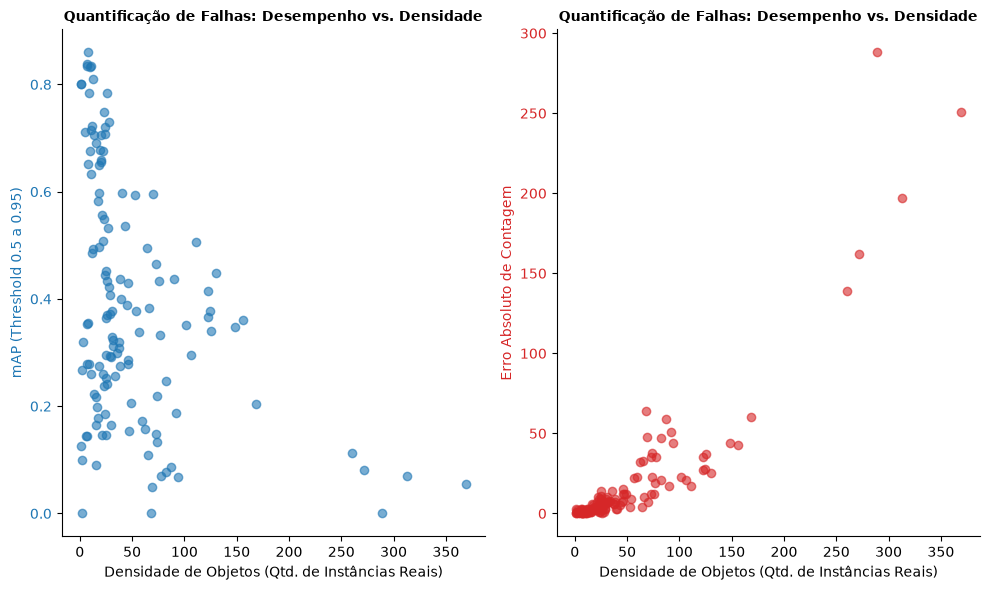

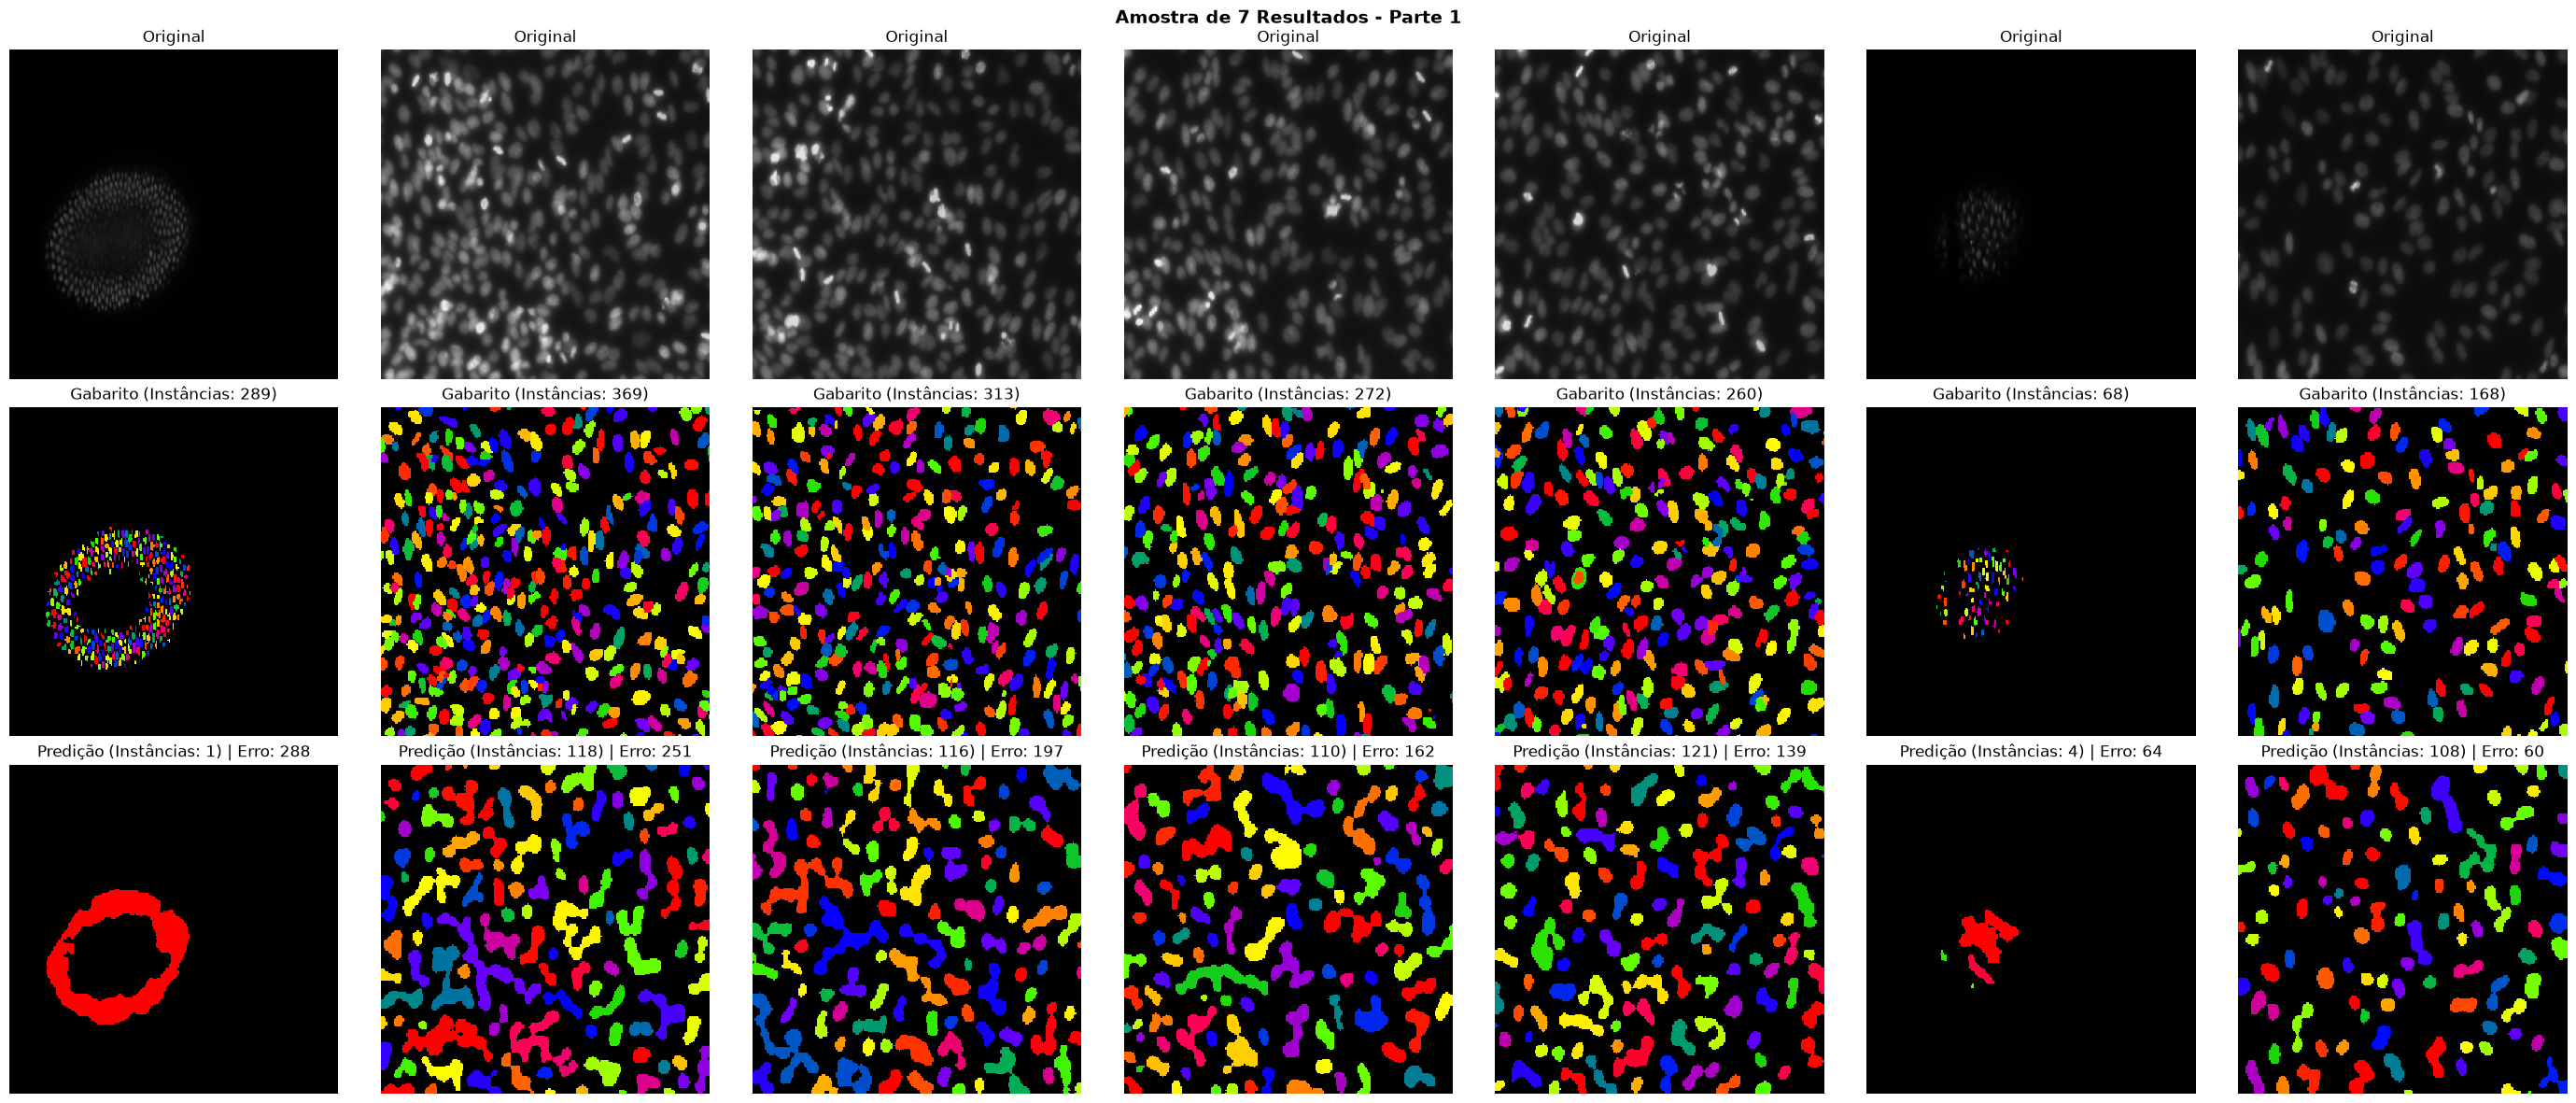

In [ ]:
model_binary.load_state_dict(torch.load('../models/best_model_binary.pt', map_location=DEVICE, weights_only=True))

aps_binary, count_errors_binary, densities_binary, per_image_aps_binary, samples_binary = evaluate_instances_binary(model_binary, val_loader_binary)

for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]} : {aps_binary[i]} | {per_image_aps_binary[i]}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_binary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_binary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_binary):.4f}")

plot_metrics(per_image_aps_binary, count_errors_binary, densities_binary)
plot_samples(samples_binary)

### Parte 2

Primeiramente vamos usar os dados sintéticos:

In [ ]:
model_s2 = UNetTernary().to(DEVICE)
full_ds_s2 = DSB2018TernaryDataset(PATH_TRAIN)
train_ds_s2, val_ds_s2train_ds_s2 = random_split(full_ds_s2, split(len(full_ds_s2)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_s2)} amostras | Val: {len(val_ds_s2train_ds_s2)} amostras')

train_loader_s2 = DataLoader(train_ds_s2, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_s2 = DataLoader(val_ds_s2train_ds_s2, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)



start_s2 = time.time()
history_s2 = train_model_ternary(model_s2, train_loader_s2, val_loader_s2, "s2")
print(f"Tempo de treinamento: {(time.time() - start_s2)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_s2['val_iou']):.4f}")
print(f"Dice corresp.: {history_s2['val_dice'][-1]:.4f}")
plot_training_curves_ternary(history_s2)


model_s2.load_state_dict(torch.load('../models/best_model_s2.pt', map_location=DEVICE, weights_only=True))

aps_s2, count_errors_s2, densities_s2, per_image_aps_s2, samples_s2 = evaluate_instances_watershed(model_s2, val_loader_s2)

for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]} : {aps_s2[i]} | {per_image_aps_s2[i]}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_s2):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_s2):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_s2):.4f}")

plot_metrics(per_image_aps_s2, count_errors_s2, densities_s2)
plot_samples(samples_s2)

Agora vamos para os dados reais:

In [ ]:
model_ternary = UNetTernary().to(DEVICE)
full_ds_ternary = DSB2018TernaryDataset(PATH_TRAIN)
train_ds_ternary, val_ds_ternarytrain_ds_ternary = random_split(full_ds_ternary, split(len(full_ds_ternary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ternary)} amostras | Val: {len(val_ds_ternarytrain_ds_ternary)} amostras')

train_loader_ternary = DataLoader(train_ds_ternary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_ternary = DataLoader(val_ds_ternarytrain_ds_ternary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)

In [ ]:
start_ternary = time.time()
history_ternary = train_model_ternary(model_ternary, train_loader_ternary, val_loader_ternary, "ternary")
print(f"Tempo de treinamento: {(time.time() - start_ternary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_ternary['val_iou']):.4f}")
print(f"Dice corresp.: {history_ternary['val_dice'][-1]:.4f}")
plot_training_curves_ternary(history_ternary)


In [ ]:
model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

aps_ternary, count_errors_ternary, densities_ternary, per_image_aps_ternary, samples_ternary = evaluate_instances_watershed(model_ternary, val_loader_ternary)

for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]} : {aps_ternary[i]} | {per_image_aps_ternary[i]}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_ternary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_ternary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_ternary):.4f}")

plot_metrics(per_image_aps_ternary, count_errors_ternary, densities_ternary)
plot_samples(samples_ternary)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

### Parte 3

In [ ]:
model_ternary = UNetTernary().to(DEVICE)
full_ds_ternary = DSB2018TernaryDataset(PATH_TRAIN)
train_ds_ternary, val_ds_ternarytrain_ds_ternary = random_split(full_ds_ternary, split(len(full_ds_ternary)), generator=torch.Generator().manual_seed(SEED))
print(f'Train: {len(train_ds_ternary)} amostras | Val: {len(val_ds_ternarytrain_ds_ternary)} amostras')

train_loader_ternary = DataLoader(train_ds_ternary, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_ternary, pin_memory=True)
val_loader_ternary = DataLoader(val_ds_ternarytrain_ds_ternary, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_ternary, pin_memory=True)



start_ternary = time.time()
history_ternary = train_model_ternary(model_ternary, train_loader_ternary, val_loader_ternary, "ternary")
print(f"Tempo de treinamento: {(time.time() - start_ternary)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history_ternary['val_iou']):.4f}")
print(f"Dice corresp.: {history_ternary['val_dice'][-1]:.4f}")
plot_training_curves_ternary(history_ternary)


model_ternary.load_state_dict(torch.load('../models/best_model_ternary.pt', map_location=DEVICE, weights_only=True))

aps_ternary, count_errors_ternary, densities_ternary, per_image_aps_ternary, samples_ternary = evaluate_instances_watershed(model_ternary, val_loader_ternary)

for i in range(len(IOU_THRESHOLDS)):
    print(f"{IOU_THRESHOLDS[i]} : {aps_ternary[i]} | {per_image_aps_ternary[i]}")
    
print(f'mAP (IoU 0.50:0.95): {np.mean(aps_ternary):.4f}')
print(f"Média mAP: {np.mean(per_image_aps_ternary):.4f}")
print(f"Média Erro Absoluto: {np.mean(count_errors_ternary):.4f}")

plot_metrics(per_image_aps_ternary, count_errors_ternary, densities_ternary)
plot_samples(samples_ternary)

Parte 4

In [ ]:
mosaic_img, mosaic_inst = create_mosaic_real(real_val, indices=[0, 1, 2, 3])

print(f"📦 Formato da imagem do mosaico: {mosaic_img.shape}")
print(f"🏷️ Formato da máscara de instâncias do mosaico: {mosaic_inst.shape}")
print(f"🔢 Total de instâncias únicas no mosaico: {len(np.unique(mosaic_inst)) - 1}")



In [ ]:

tiles, coords = mosaic_tile_inference_demo(mosaic_img, tile_size=128, overlap=32)

print(f"🧩 Número total de tiles gerados: {len(tiles)}")
print(f"📍 Coordenadas (y_start, y_end, x_start, x_end) do primeiro tile: {coords[0]}")
print(f"📦 Formato de cada tile: {tiles[0].shape}")

In [ ]:


real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start_binary = time.time()
train_model(real_model, real_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start_binary) / 60:.2f} minutes")
real_mAP, real_count_errors, real_densities, synthetic_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(synthetic_samples, part=1)




real_model.to(device)
# 1. Inferência Ingênua (Antes da correção)
pred_naive = mosaic_inference_naive(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_naive, err_naive, _ = calculate_instance_metrics(mosaic_inst, pred_naive)


In [ ]:
# 2. Inferência com Fusão (Depois da correção)
pred_fusion = mosaic_inference_with_fusion(real_model, mosaic_img, tile_size=128, overlap=32, device=device)
map_fusion, err_fusion, _ = calculate_instance_metrics(mosaic_inst, pred_fusion)

print(f"❌ ANTES (Ingênuo): mAP = {map_naive:.4f} | Erro de Contagem = {err_naive}")
print(f"✅ DEPOIS (Fusão) : mAP = {map_fusion:.4f} | Erro de Contagem = {err_fusion}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(mosaic_inst, cmap='nipy_spectral')
axes[0].set_title("Ground Truth (Mosaico 256x256)")
axes[0].axis('off')

axes[1].imshow(pred_naive, cmap='nipy_spectral')
axes[1].set_title(f"Predição Ingênua\n(Note os cortes nas bordas)\nmAP: {map_naive:.4f}")
axes[1].axis('off')

axes[2].imshow(pred_fusion, cmap='nipy_spectral')
axes[2].set_title(f"Predição com Fusão por Intersecção\n(Bordas Corrigidas)\nmAP: {map_fusion:.4f}")
axes[2].axis('off')



# Definindo a região do zoom (exemplo de uma janela de 60x60 pixels)
zoom_x_min, zoom_x_max = 90, 150
zoom_y_min, zoom_y_max = 90, 150

for ax in axes:
    ax.set_xlim(zoom_x_min, zoom_x_max)
    ax.set_ylim(zoom_y_max, zoom_y_min) # Y é invertido no imshow (de cima para baixo)

plt.tight_layout()
plt.show()